# Experimento 2: Selección del Umbral de Confianza — YOLOv8

**Objetivo:** Justificar con datos qué umbral de confianza usar en el sistema final
de asistencia. Se compara el detector con tres umbrales (**0.3, 0.5 y 0.7**) sobre los
mismos videos del Experimento 1, midiendo por umbral: detecciones totales, falsos
positivos (revisados visualmente), rostros reales perdidos (falsos negativos) y
confianza promedio de las detecciones aceptadas.

**Dependencia:** este experimento parte del detector base validado en
`exp1_deteccion_base.ipynb`.


In [2]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# El notebook esta en experiments/, la raiz del proyecto es un nivel arriba
RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from src.detector import FaceDetector

print("Imports completados.")

Imports completados.


## Metodologia

Como es el mismo modelo, las detecciones a un umbral alto son un **subconjunto** de las
de un umbral bajo: `det(0.7) ⊆ det(0.5) ⊆ det(0.3)`. Por eso, en vez de hacer tres
pasadas de inferencia, hacemos **una sola pasada al umbral mas bajo (0.3)** y obtenemos
los otros dos umbrales filtrando por confianza. Es matematicamente equivalente a correr
el detector tres veces, pero mas eficiente y con una contabilidad de FP/FN consistente.

**Definiciones:**
- **Detecciones totales (a umbral T):** cajas con confianza `>= T`.
- **Falsos positivos (FP):** cajas que NO son rostros. Se revisan **visualmente** sobre
  una muestra de ~25 frames por video y se anotan a mano.
- **Rostros perdidos / falsos negativos (FN):** rostros **reales** (presentes en la
  referencia del umbral base 0.3) cuya confianza cae por debajo de T, por lo que dejan
  de detectarse al subir el umbral.
- **Confianza promedio aceptada:** media de la confianza de las cajas con `conf >= T`.

In [3]:
# Configuracion del experimento
UMBRALES = [0.3, 0.5, 0.7]
UMBRAL_BASE = min(UMBRALES)   # referencia para los falsos negativos
N_MUESTRA = 25                # frames muestreados por video para la revision visual

# El detector se carga en el umbral base: una sola pasada captura todas las
# detecciones candidatas y los umbrales superiores se obtienen filtrando.
DETECTOR = FaceDetector(str(RAIZ / "models" / "yolov8n-face.pt"), conf_threshold=UMBRAL_BASE)

RUTA_VIDEOS = RAIZ / "dataset" / "test_videos"
videos = sorted(RUTA_VIDEOS.glob("*.mp4"))
if not videos:
    raise FileNotFoundError(f"No se encontraron videos .mp4 en {RUTA_VIDEOS}")

print(f"Umbrales a comparar: {UMBRALES}")
print(f"Umbral base (referencia FN): {UMBRAL_BASE}")
print(f"Videos encontrados ({len(videos)}): {[v.name for v in videos]}")

Umbrales a comparar: [0.3, 0.5, 0.7]
Umbral base (referencia FN): 0.3
Videos encontrados (2): ['video_corto_prueba.mp4', 'video_prueba_taco.mp4']


## 1. Muestreo de frames y deteccion al umbral base

Se toman `N_MUESTRA` frames distribuidos uniformemente a lo largo de cada video y se
ejecuta la deteccion al umbral base (0.3). Cada caja detectada recibe un identificador
global `#id` que servira para anotar manualmente los falsos positivos.

In [4]:
def frames_muestreados(ruta_video, n):
    """Devuelve n indices de frame distribuidos uniformemente en el video."""
    cap = cv2.VideoCapture(str(ruta_video))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    if total <= 0:
        return []
    n = min(n, total)
    return [int(round(i)) for i in np.linspace(0, total - 1, n)]


detecciones = []          # una fila por deteccion candidata (conf >= UMBRAL_BASE)
muestras_por_video = {}   # nombre_video -> lista de (frame_idx, imagen_anotada)

det_id = 0
for ruta in videos:
    nombre = ruta.name
    indices = frames_muestreados(ruta, N_MUESTRA)
    muestras_por_video[nombre] = []
    cap = cv2.VideoCapture(str(ruta))
    for f_idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        dets = DETECTOR.detect(frame, conf=UMBRAL_BASE)
        anotado = frame.copy()
        for (x1, y1, x2, y2, conf) in dets:
            detecciones.append({
                "id": det_id,
                "video": nombre,
                "frame": f_idx,
                "conf": round(float(conf), 3),
            })
            cv2.rectangle(anotado, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(anotado, f"#{det_id} {conf:.2f}", (x1, max(y1 - 6, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            det_id += 1
        muestras_por_video[nombre].append((f_idx, anotado))
    cap.release()

df_det = pd.DataFrame(detecciones)
print(f"Frames muestreados en total: {sum(len(v) for v in muestras_por_video.values())}")
print(f"Detecciones candidatas (conf >= {UMBRAL_BASE}): {len(df_det)}")
df_det.head()

Frames muestreados en total: 50
Detecciones candidatas (conf >= 0.3): 50


,id,video,frame,conf
0,0,video_corto_prueba.mp4,0,0.849
1,1,video_corto_prueba.mp4,8,0.836
2,2,video_corto_prueba.mp4,16,0.847
3,3,video_corto_prueba.mp4,24,0.850
4,4,video_corto_prueba.mp4,32,0.846


## 2. Laminas de revision visual

Se genera una lamina ("contact sheet") por video con todos los frames muestreados y sus
cajas numeradas. Las imagenes tambien se guardan en `experiments/graphs/` para que puedas
ampliarlas e identificar comodamente los falsos positivos.

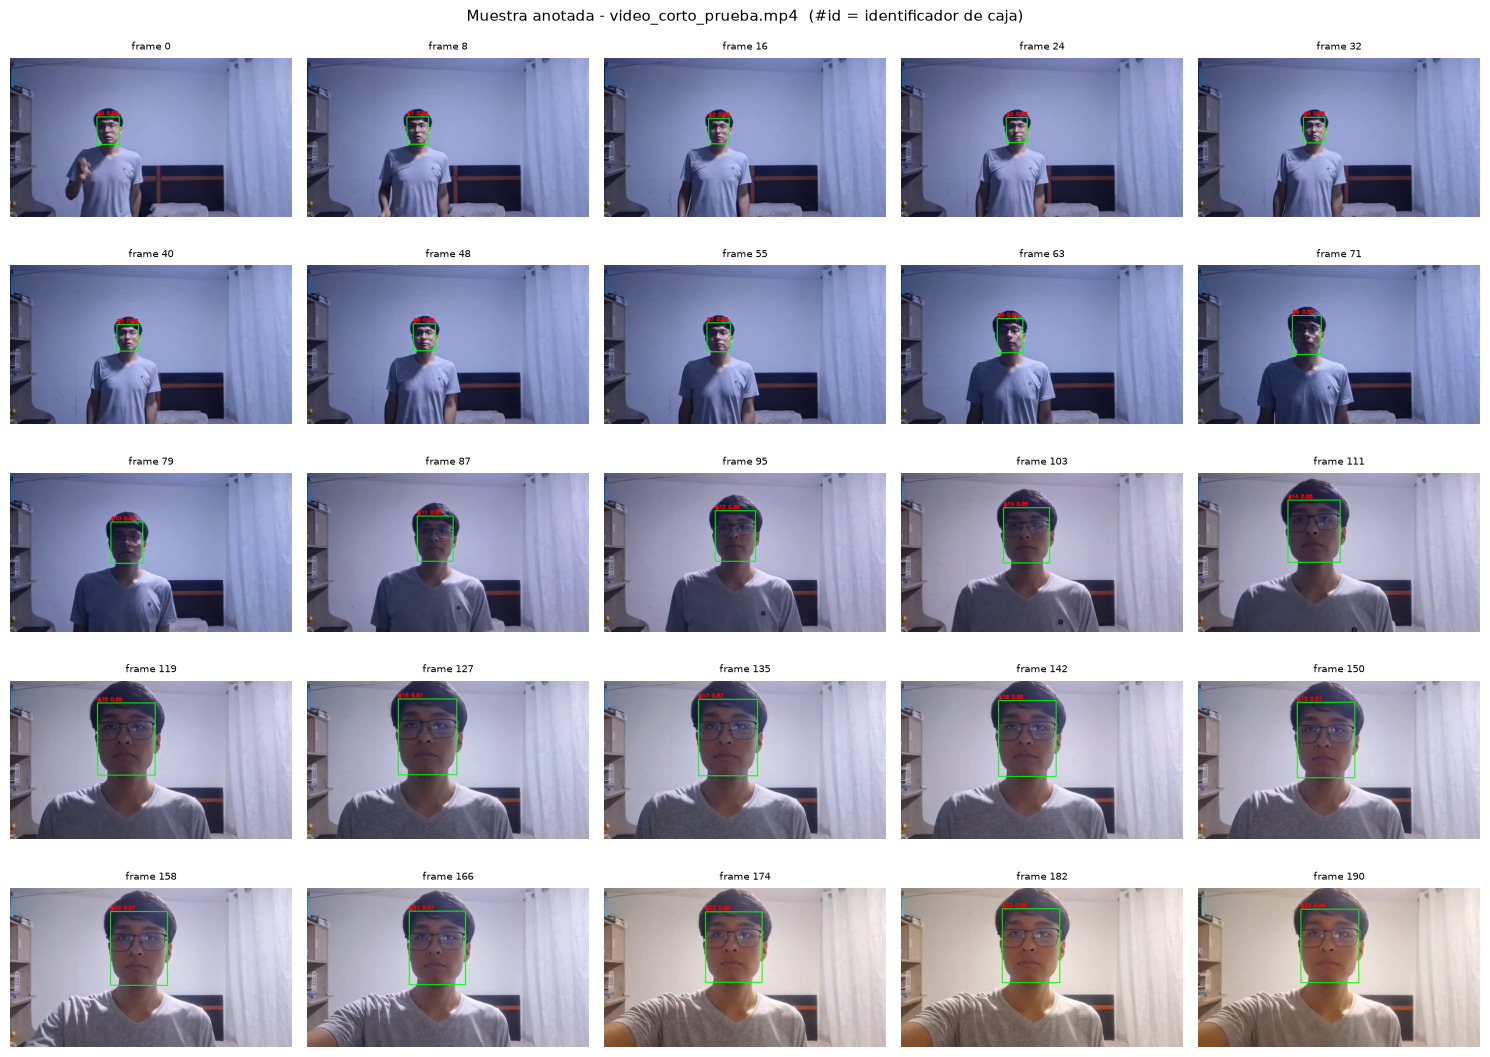

Guardado: c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\graphs\exp2_muestra_video_corto_prueba.png


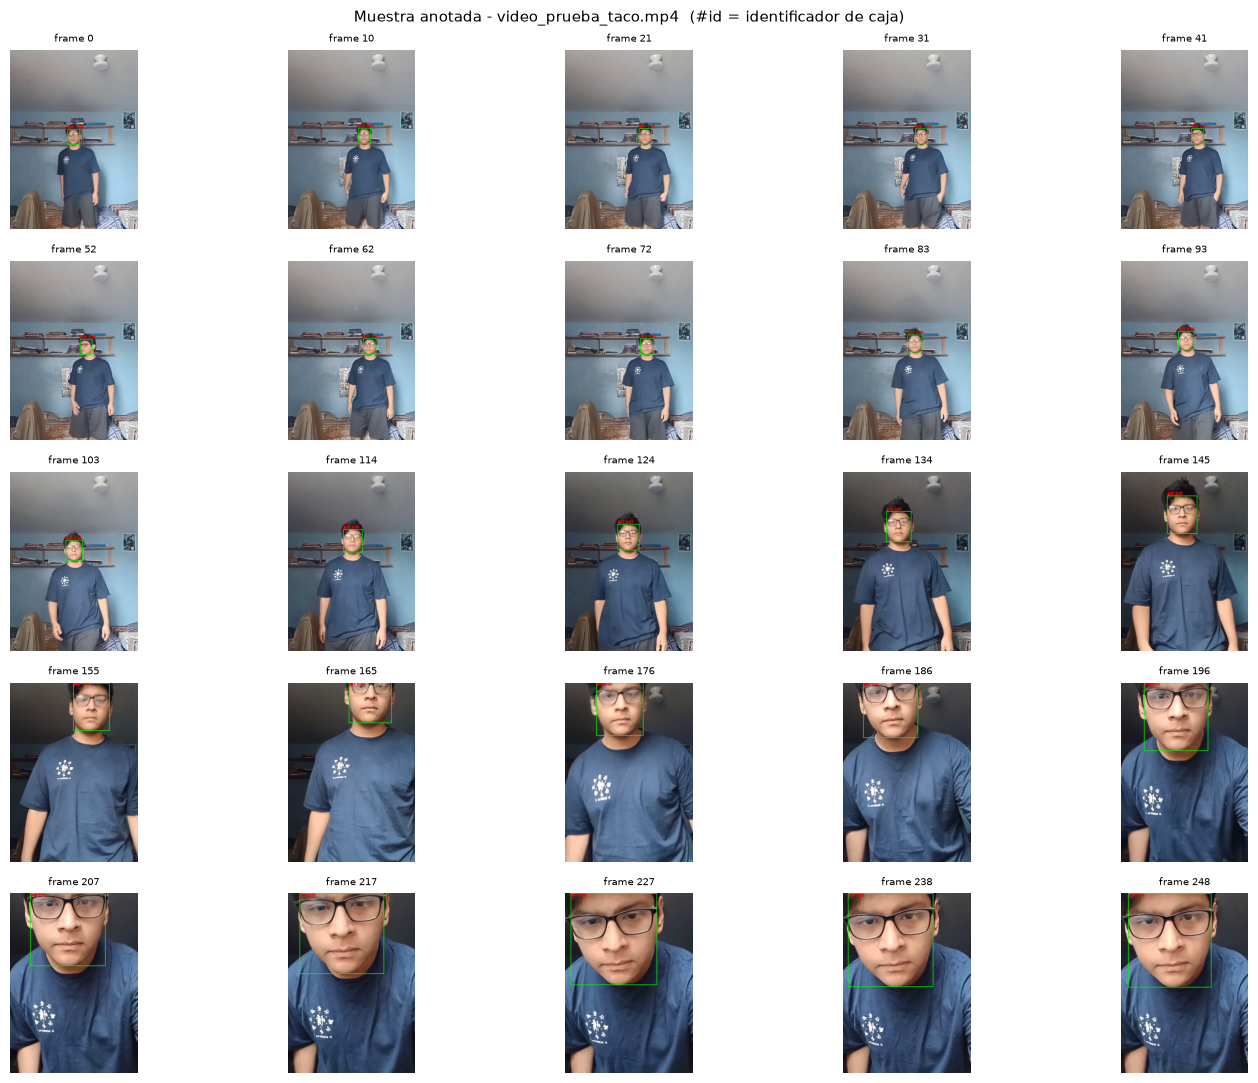

Guardado: c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\graphs\exp2_muestra_video_prueba_taco.png


In [5]:
GRAPHS = RAIZ / "experiments" / "graphs"
GRAPHS.mkdir(parents=True, exist_ok=True)

for nombre, muestras in muestras_por_video.items():
    n = len(muestras)
    cols = 5
    filas = int(np.ceil(n / cols)) if n else 1
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3, filas * 2.2))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, (f_idx, img) in zip(axes, muestras):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame {f_idx}", fontsize=7)
    fig.suptitle(f"Muestra anotada - {nombre}  (#id = identificador de caja)", fontsize=11)
    plt.tight_layout()
    salida = GRAPHS / f"exp2_muestra_{Path(nombre).stem}.png"
    plt.savefig(salida, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {salida}")

## 3. Anotacion manual de falsos positivos
Al no encontrar falsos positivos, se deja vacío : set()

In [10]:
FALSOS_POSITIVOS_IDS = set()

ids_validos = set(df_det["id"]) if len(df_det) else set()
desconocidos = FALSOS_POSITIVOS_IDS - ids_validos
if desconocidos:
    raise ValueError(f"Estos ids no existen entre las detecciones: {sorted(desconocidos)}")

print(f"Falsos positivos anotados: {len(FALSOS_POSITIVOS_IDS)} -> {sorted(FALSOS_POSITIVOS_IDS)}")

Falsos positivos anotados: 0 -> []


## 4. Tabla comparativa de umbrales

Para cada umbral se cuentan las detecciones aceptadas, cuantas de ellas son falsos
positivos, cuantos rostros reales se pierden respecto a la referencia (0.3) y la confianza
promedio de lo aceptado.

In [11]:
if len(df_det):
    df_det["es_fp"] = df_det["id"].isin(FALSOS_POSITIVOS_IDS)
else:
    df_det["es_fp"] = pd.Series(dtype=bool)

# Rostros reales de referencia: detecciones del umbral base que SI son rostros.
reales = df_det[~df_det["es_fp"]]

filas = []
for u in UMBRALES:
    aceptadas = df_det[df_det["conf"] >= u]
    fp = int(aceptadas["es_fp"].sum())
    perdidos = int((reales["conf"] < u).sum())
    conf_prom = round(float(aceptadas["conf"].mean()), 3) if len(aceptadas) else 0.0
    filas.append({
        "umbral": u,
        "detecciones_totales": int(len(aceptadas)),
        "falsos_positivos": fp,
        "rostros_perdidos": perdidos,
        "confianza_promedio_aceptadas": conf_prom,
    })

df_exp2 = pd.DataFrame(filas)
display(df_exp2)

,umbral,detecciones_totales,falsos_positivos,rostros_perdidos,confianza_promedio_aceptadas
0,0.3,50,0,0,0.866
1,0.5,50,0,0,0.866
2,0.7,50,0,0,0.866


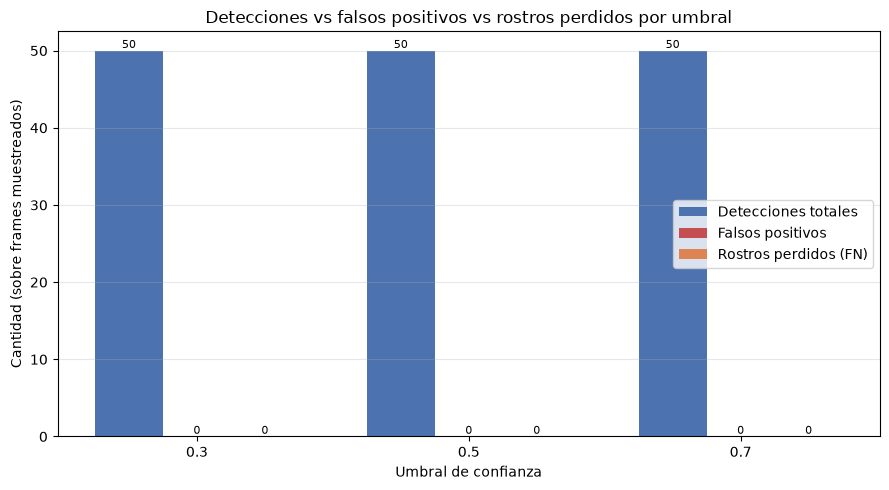

In [12]:
# Grafico de barras: detecciones vs falsos positivos vs rostros perdidos por umbral
x = np.arange(len(UMBRALES))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho, df_exp2["detecciones_totales"], ancho, label="Detecciones totales", color="#4C72B0")
ax.bar(x,         df_exp2["falsos_positivos"],   ancho, label="Falsos positivos",   color="#C44E52")
ax.bar(x + ancho, df_exp2["rostros_perdidos"],   ancho, label="Rostros perdidos (FN)", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels([str(u) for u in UMBRALES])
ax.set_xlabel("Umbral de confianza")
ax.set_ylabel("Cantidad (sobre frames muestreados)")
ax.set_title("Detecciones vs falsos positivos vs rostros perdidos por umbral")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for cont in ax.containers:
    ax.bar_label(cont, fontsize=8)

plt.tight_layout()
plt.savefig(GRAPHS / "exp2_comparacion_umbrales.png", dpi=150)
plt.show()

In [ ]:
# Guardar resultados a CSV
df_exp2.to_csv(RAIZ / "experiments" / "resultados_exp2.csv", index=False)
print("Resultados guardados en experiments/resultados_exp2.csv")

# Recomendacion basada en datos: minimizar (falsos positivos + rostros perdidos);

df_score = df_exp2.copy()
df_score["errores"] = df_score["falsos_positivos"] + df_score["rostros_perdidos"]
mejor = df_score.sort_values(["errores", "umbral"]).iloc[0]
print(f"\nUmbral sugerido por la metrica de errores (FP + FN): {mejor['umbral']}")
print(f"  -> falsos_positivos={int(mejor['falsos_positivos'])}, "
      f"rostros_perdidos={int(mejor['rostros_perdidos'])}")

Resultados guardados en experiments/resultados_exp2.csv

Umbral sugerido por la metrica de errores (FP + FN): 0.3
  -> falsos_positivos=0, rostros_perdidos=0


## 5. Conclusion: umbral seleccionado

### Lectura de la tabla

Al comparar el detector con umbrales 0.3, 0.5 y 0.7 sobre los dos videos de prueba, los
tres umbrales arrojaron **resultados identicos**: 50 detecciones, **0 falsos positivos** y
**0 rostros perdidos** en cada caso, con una confianza promedio de **0.866**. Esto se debe
a que todas las detecciones obtenidas tienen una confianza muy alta (>= 0.7), consistente
con el Experimento 1, donde la confianza promedio fue ~0.86. Como los integrantes del grupo
aparecen de frente, cerca de la camara y con buena iluminacion, el detector reconoce los
rostros con gran seguridad y no genera detecciones dudosas en la franja 0.3-0.7, que es
justamente donde el umbral marcaria diferencia. Por eso las tres barras del grafico salen
iguales.

### Umbral seleccionado: **0.5**

Dado que ningun umbral es superior a otro segun los datos, la decision se toma por
**robustez de cara al uso real del sistema**, no solo por los videos de prueba:

1. **Descartamos 0.3.** En condiciones menos favorables que las de los videos de prueba
   (fondos complejos, objetos, ropa, mala luz), un umbral tan permisivo aumentaria el
   riesgo de falsos positivos. No aparecieron aqui solo porque los videos son "faciles".
2. **Descartamos 0.7.** Seria demasiado estricto y podria perder rostros reales captados en
   angulos dificiles, contraluz o a distancia, donde la confianza baja por debajo de 0.7.
3. **Elegimos 0.5 como valor de equilibrio.** Ofrece margen de seguridad frente a falsos
   positivos sin sacrificar la deteccion de rostros reales en condiciones adversas, y en
   nuestros datos no cuesta nada (todas las detecciones superan 0.7 igual). Ademas coincide
   con el umbral validado en el Experimento 1, manteniendo coherente todo el pipeline del
   sistema.

**Conclusion:** se selecciona el umbral de confianza **0.5** para el sistema de control de
asistencia.